# Logistic Regression

Overview
--------
This script trains a **single linear (logistic regression) classifier** on the flattened
64×64 grayscale Chinese MNIST images. It explores a small hyperparameter grid across
batch size, optimizer, and learning rate, evaluates all saved checkpoints on the test set,
then reports and visualizes the best performer.

Pipeline Steps
--------------

1. Dataset preparation / validation via `preprocessing_utils.prepare_images`.
2. Construction of train / validation / test DataLoaders (optionally with light augmentation
     on the training split) via `preprocessing_utils.get_dataloaders`.
3. Definition of a single-layer linear classifier (`LogisticRegressionModel`).
4. Training across the grid:

     - batch_size: ``[32, 256]`` (NOTE: The earlier 64 value was removed to reduce runtime / memory.)
     - optimizer: ``Adam`` and ``SGD`` (SGD uses momentum=0.9)
     - learning_rate: ``[0.01, 0.001, 0.0005]`` (updated; ``0.005`` no longer used)
     - epochs: 30 (with early stopping)
     - early stopping patience: 5 epochs (monitors validation accuracy)
5. Checkpoint saving: best validation accuracy per run →

     ``checkpoints/log_reg/model_{batch}_{optimizer}_{lr}.pth``
6. Curve plotting: training / validation accuracy & loss → ``plots/log_reg/``
7. Test evaluation of every checkpoint (accuracy, macro‑F1, confusion matrix) to find best model.
8. Confusion matrix plotting for the best checkpoint.
9. Simple per‑class qualitative inference (one random test image per class) using the best model.

Key Assumptions
---------------
- Inputs passed to :class:`LogisticRegressionModel` are already **flattened** to shape
    ``(batch_size, input_dim)``. The module does **not** perform flattening internally.
- ``input_dim`` is inferred dynamically from a sample batch after the initial DataLoader creation.
- Utilities sourced from ``preprocessing_utils.py`` and ``models_utils.py`` (training loop,
    evaluation, plotting, prediction helper).
- Returned values from :func:`predict_image` are raw logits (not softmax probabilities). When
    the script prints them it labels them as *probabilities* for convenience; apply
    ``torch.softmax(logits, dim=0)`` if true probabilities are required.

Run
---
    python log_reg.py

Reproducibility / Notes
-----------------------
- Random sampling (image previews, per-class inference) is not seeded; set a manual seed if
    deterministic behavior is needed.
- Early stopping triggers when validation accuracy fails to improve for ``patience`` epochs;
    best checkpoint is preserved.

2.8.0+cpu
Using device: cpu
Dataset already exists, skipping download.
Train/Val/Test folders already exist. (Set overwrite=True to recreate them)
Dataset ready at: data
train: 12000 images, 15 classes
{'0': 800, '1': 800, '10': 800, '100': 800, '1000': 800, '10000': 800, '100000000': 800, '2': 800, '3': 800, '4': 800, '5': 800, '6': 800, '7': 800, '8': 800, '9': 800}
val: 1500 images, 15 classes
{'0': 100, '1': 100, '10': 100, '100': 100, '1000': 100, '10000': 100, '100000000': 100, '2': 100, '3': 100, '4': 100, '5': 100, '6': 100, '7': 100, '8': 100, '9': 100}
test: 1500 images, 15 classes
{'0': 100, '1': 100, '10': 100, '100': 100, '1000': 100, '10000': 100, '100000000': 100, '2': 100, '3': 100, '4': 100, '5': 100, '6': 100, '7': 100, '8': 100, '9': 100}


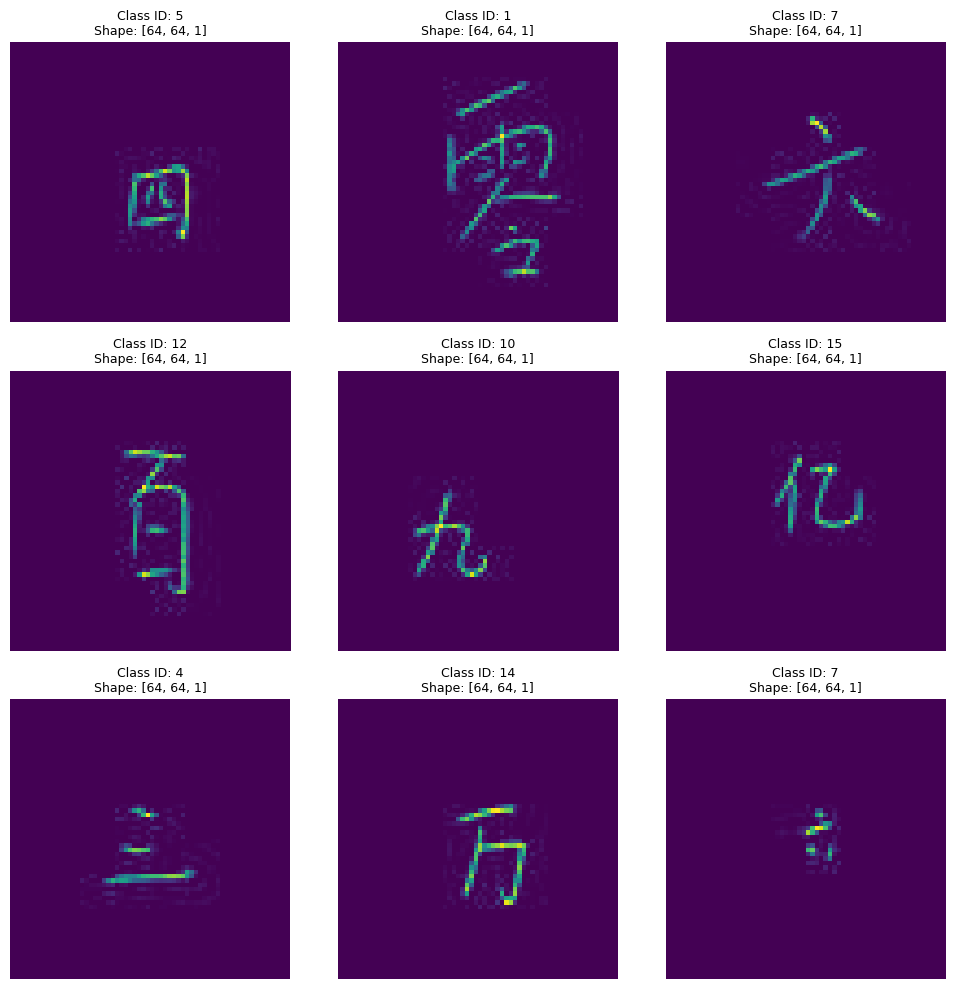

DataLoaders ready.
Classes: ['0', '1', '10', '100', '1000', '10000', '100000000', '2', '3', '4', '5', '6', '7', '8', '9']


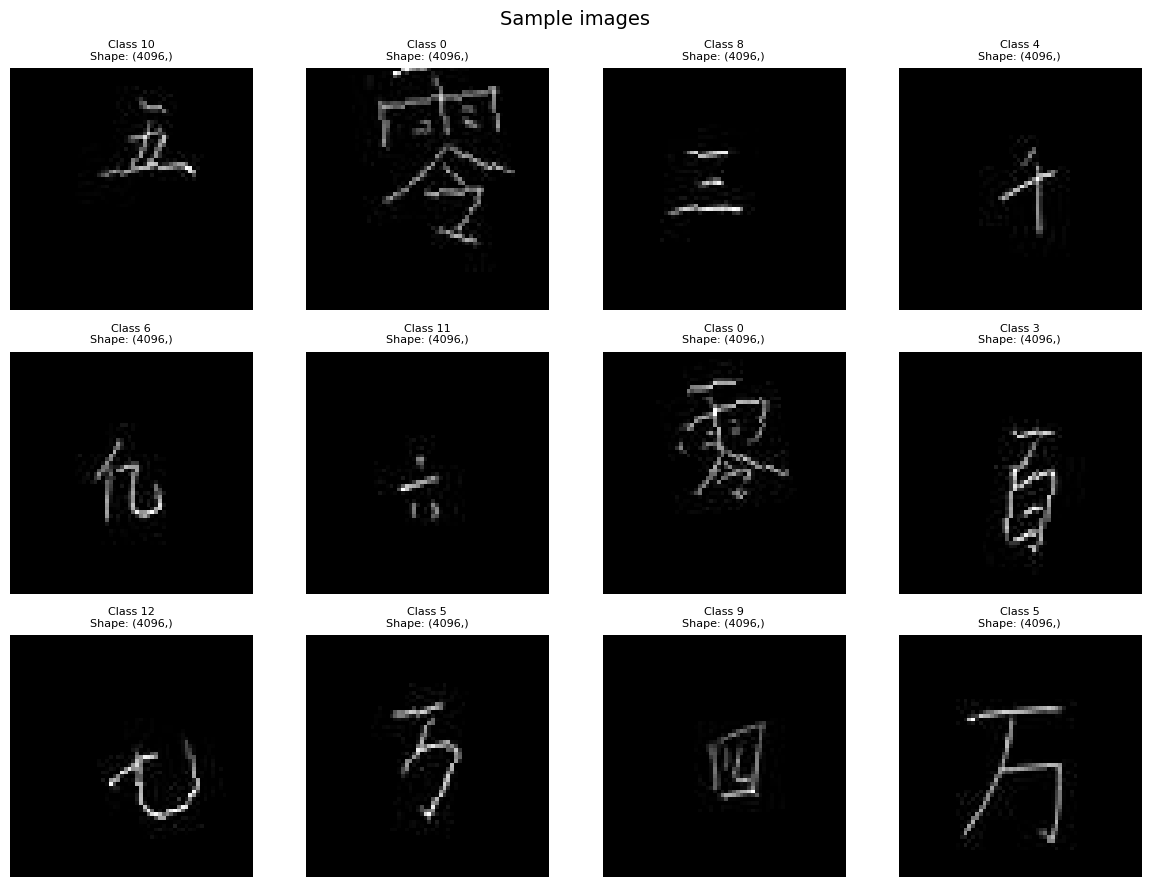

Logistic Regression summary (input_dim=4096, num_classes=15)
DataLoaders for batch size 32 ready.
DataLoaders for batch size 256 ready.

Training with batch size: 32
  Run 1: Adam optimizer with lr=0.01
Epoch 01 | Train Loss: 2.1669 | Train Acc: 0.3475 | Val Loss: 1.9132 | Val Acc: 0.4367
------------------------------------------------------------------------------------------
Model saved to checkpoints\log_reg\model_32_adam_0.01.pth
Saved new best checkpoint (epoch 1, val_acc=0.4367)
------------------------------------------------------------------------------------------
Epoch 02 | Train Loss: 2.0263 | Train Acc: 0.3997 | Val Loss: 1.8408 | Val Acc: 0.4593
------------------------------------------------------------------------------------------
Model saved to checkpoints\log_reg\model_32_adam_0.01.pth
Saved new best checkpoint (epoch 2, val_acc=0.4593)
------------------------------------------------------------------------------------------
Epoch 03 | Train Loss: 1.9777 | Train A

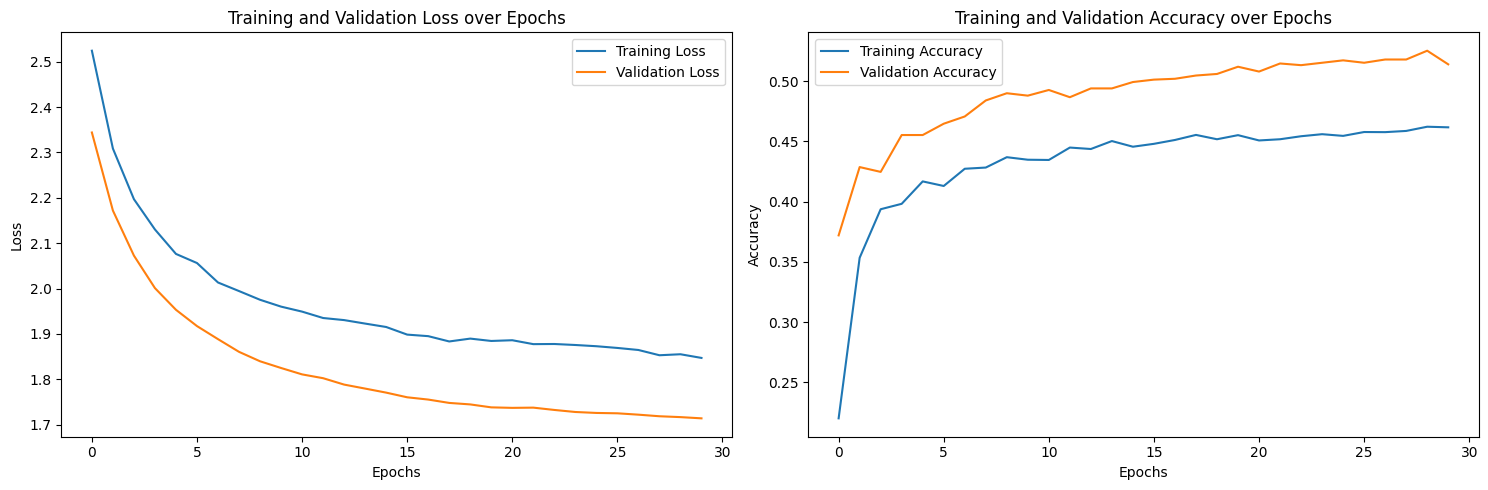

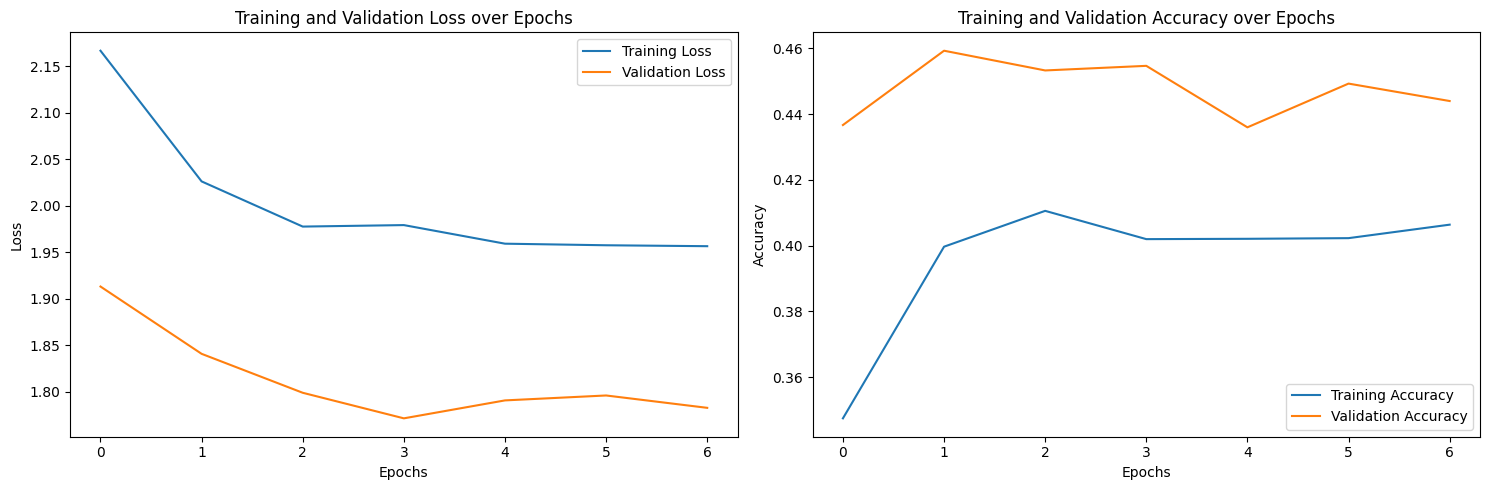

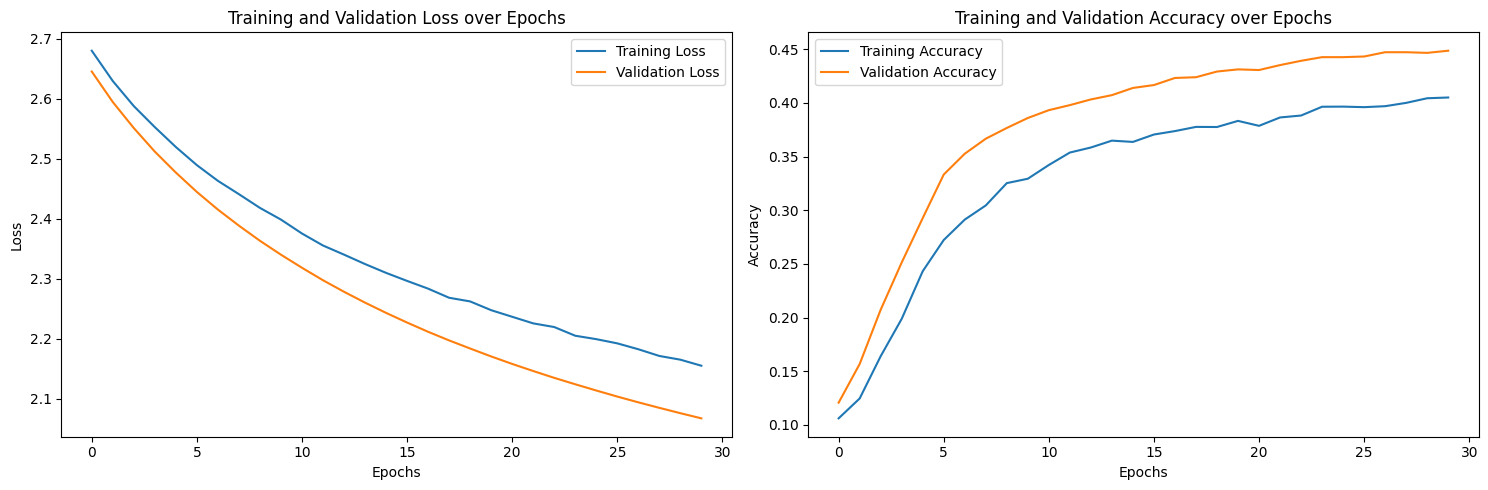

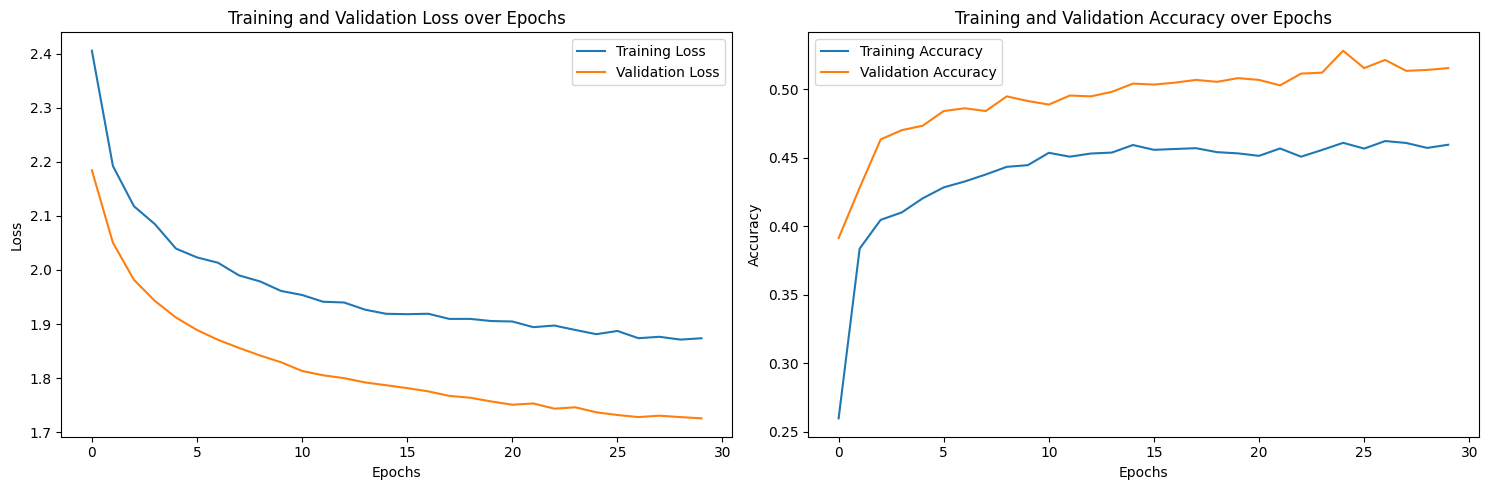

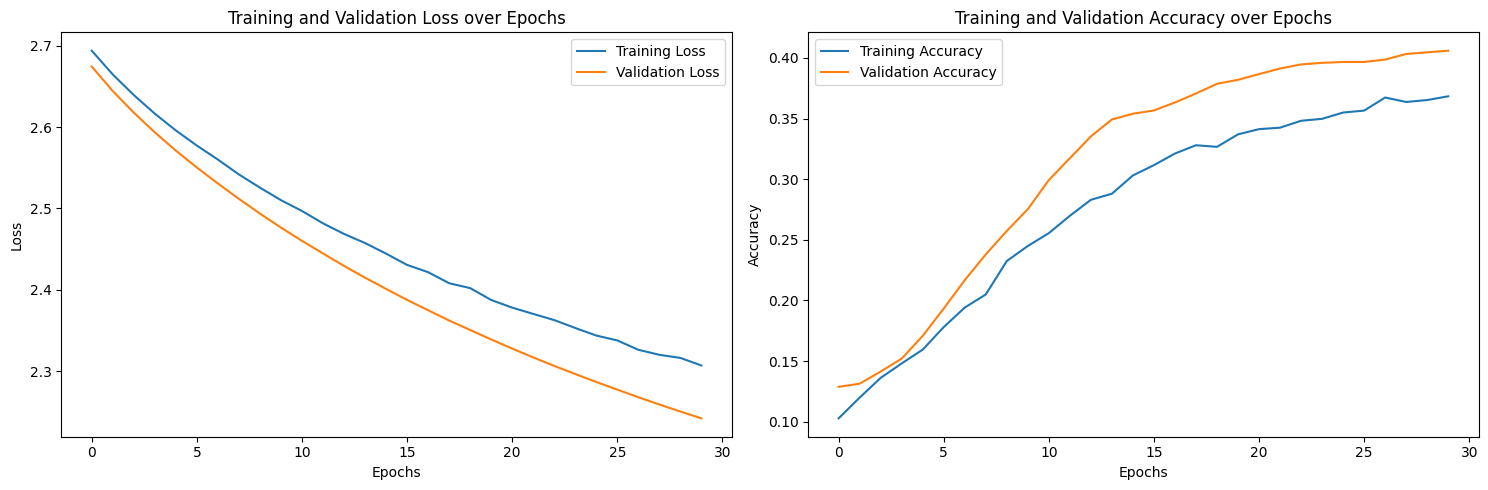

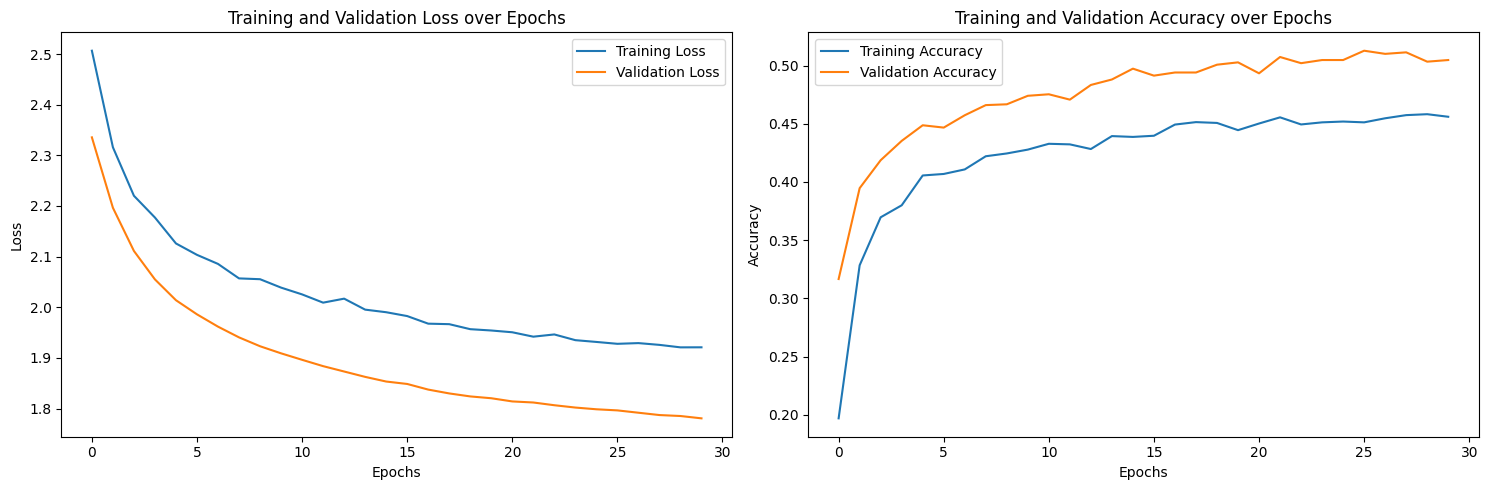

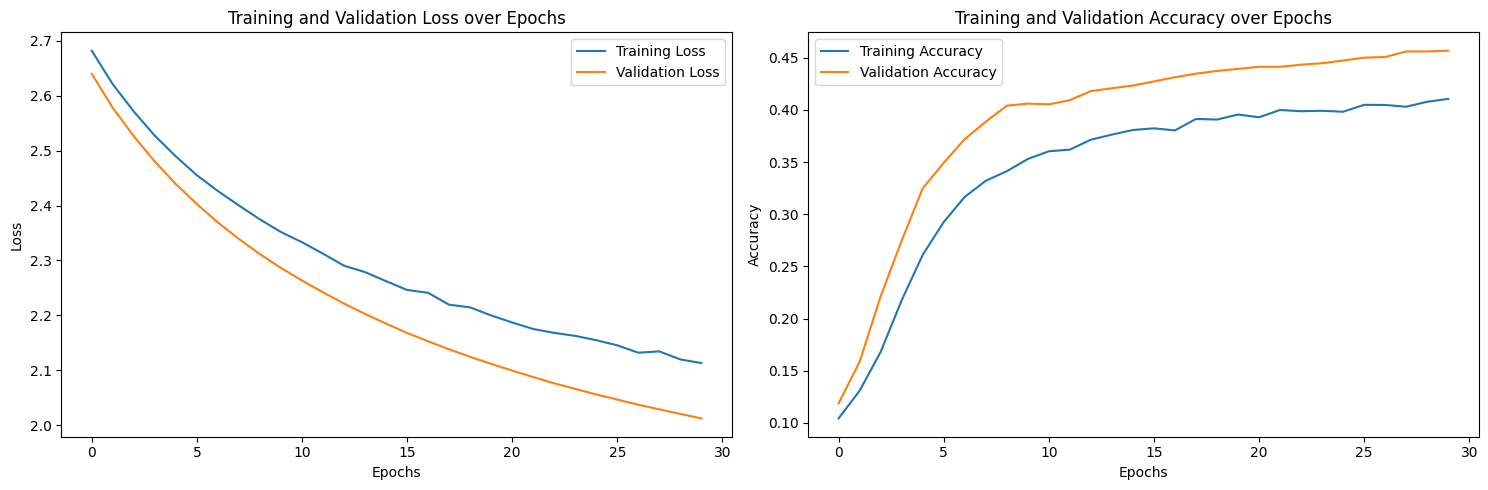

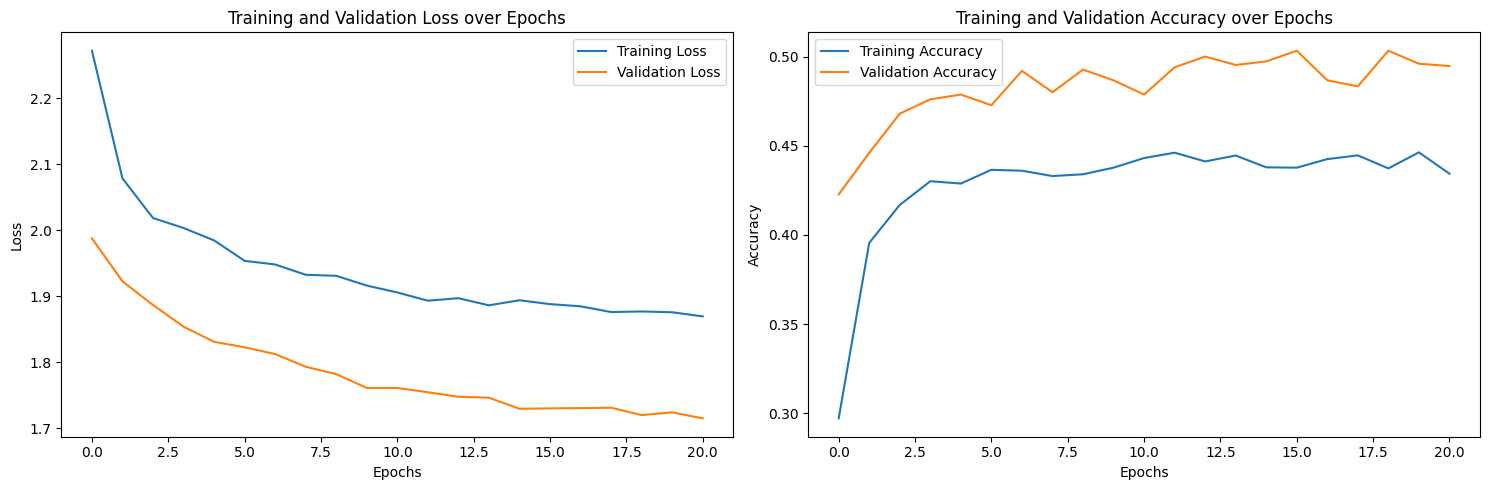

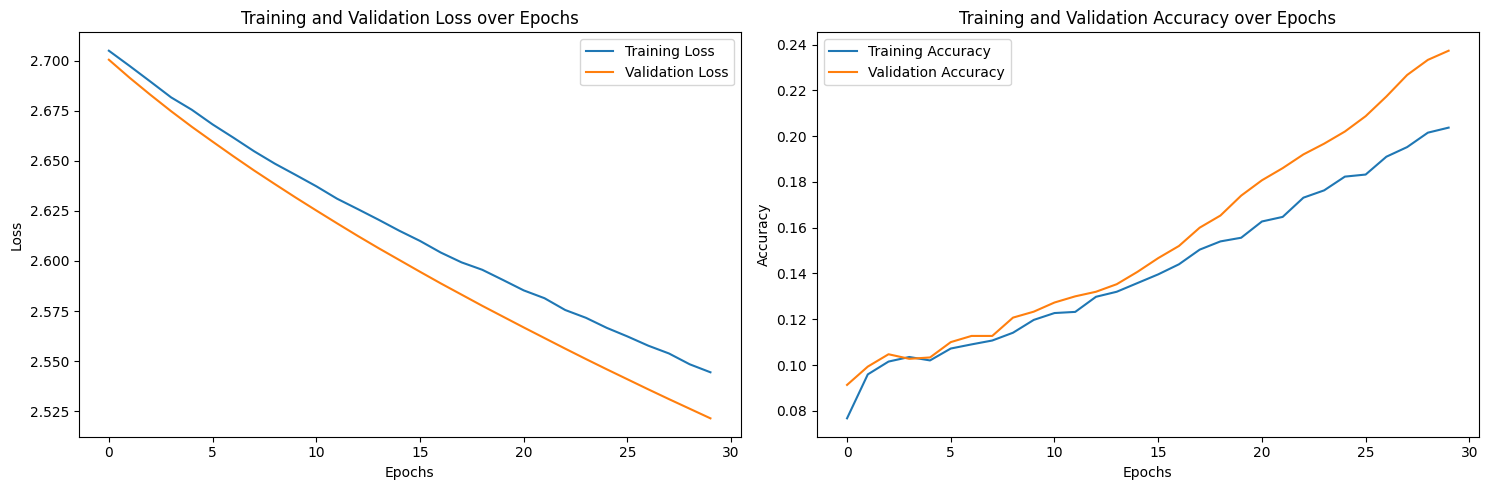

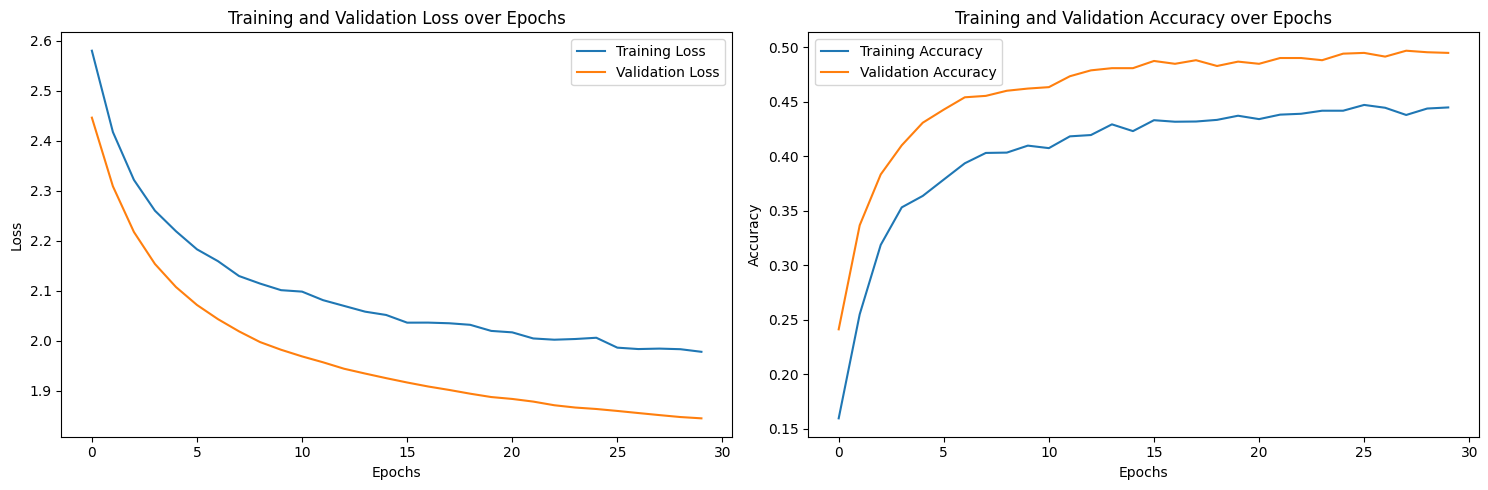

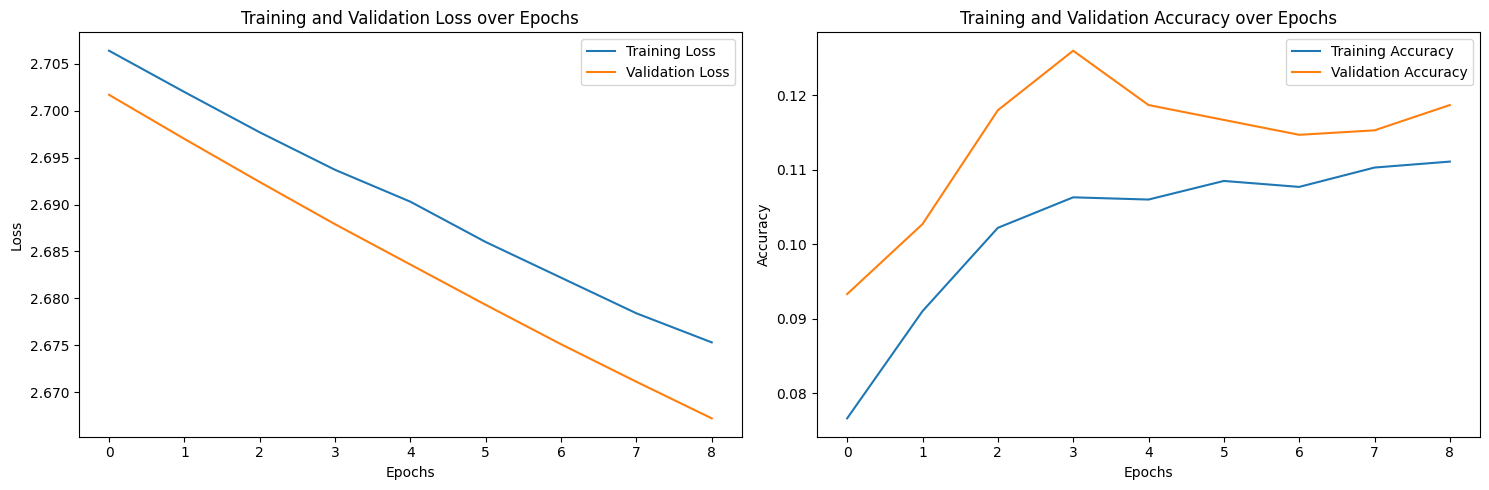

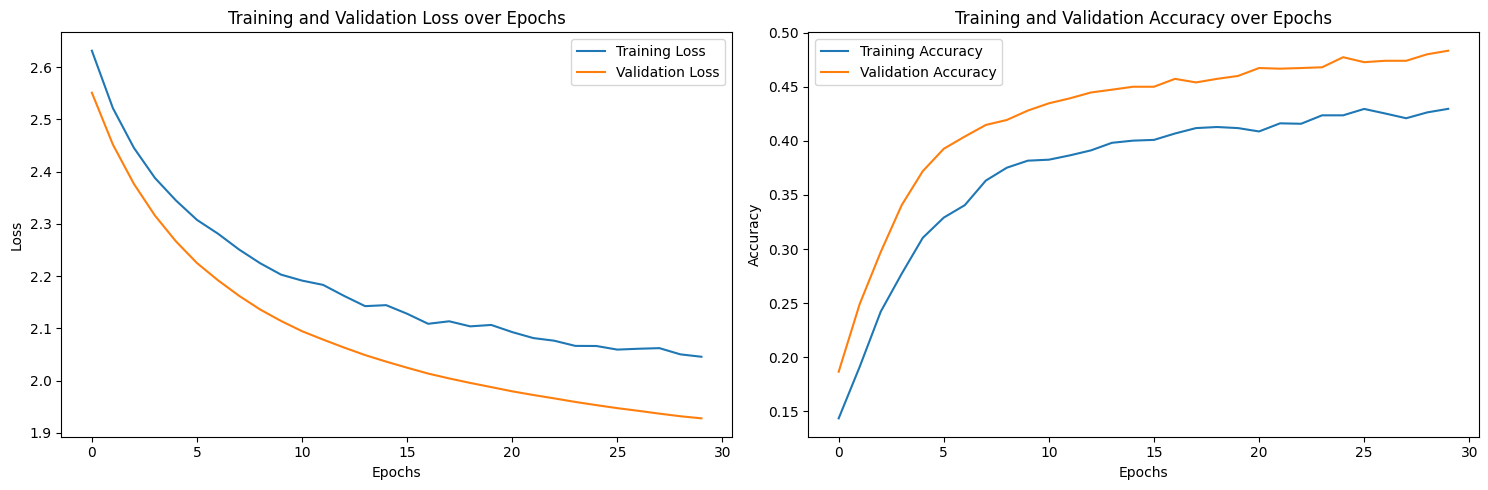

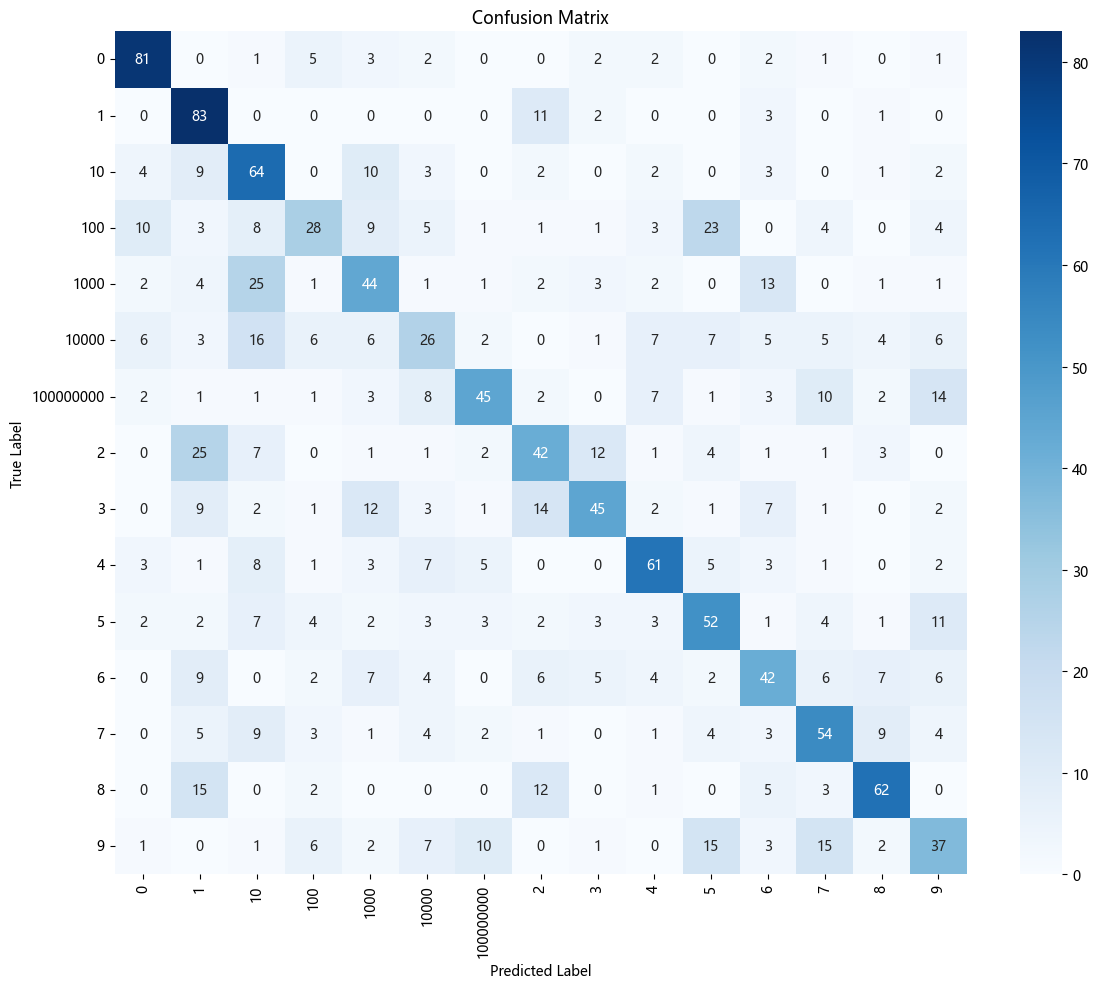

Extracted batch size: 32, optimizer: adam, learning rate: 0.001
Training process plot saved to plots/log_reg/best_model_training_process_32_0.001_adam.png
Selected image for prediction: data/test\0\input_36_8_1.jpg


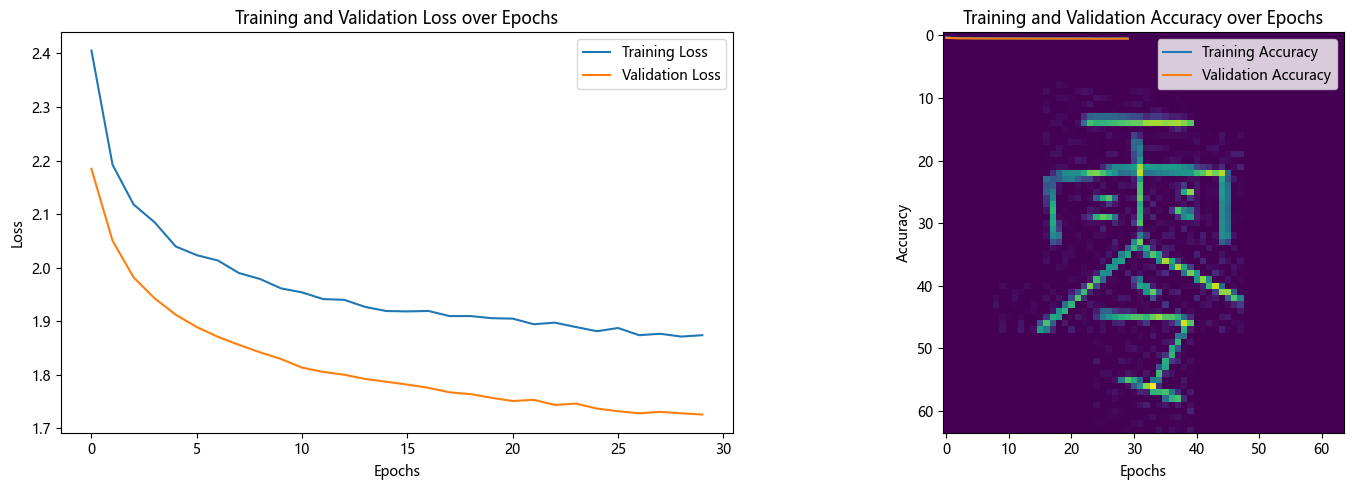

Predicted class: 0 | Logits: tensor([[  4.3776, -14.1592,  -2.1222,   2.2695,   0.6282,   2.0142,   0.1276,
          -5.6734,  -2.7065,   1.5372,   0.3536,  -2.1237,  -1.7486,  -7.4236,
           0.4744]])
Selected image for prediction: data/test\1\input_77_4_2.jpg


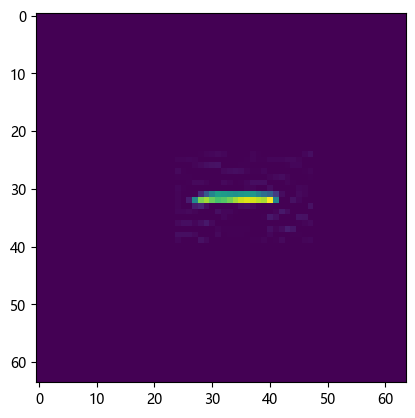

Predicted class: 1 | Logits: tensor([[-2.7699e+00,  2.1269e+00,  9.1268e-01, -1.1501e+00,  1.7018e-01,
          5.3776e-02, -1.0370e+00,  1.4597e-02, -5.5442e-01, -3.7770e-01,
         -5.8952e-01,  3.8642e-02,  1.8965e-03,  5.9346e-01, -5.1705e-01]])
Selected image for prediction: data/test\10\input_21_2_11.jpg


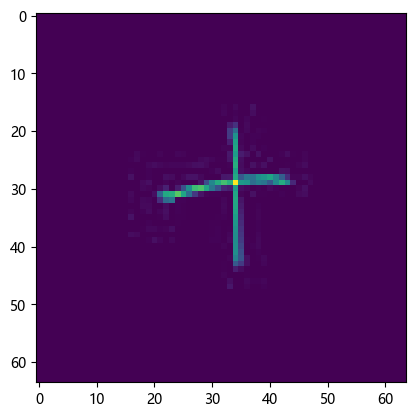

Predicted class: 10 | Logits: tensor([[-0.9344, -1.8421,  1.9875, -0.2048,  0.3120, -0.3136, -0.4879, -2.9335,
         -3.1220,  1.5694, -0.4820, -0.4040,  0.4725, -2.5727,  0.1494]])
Selected image for prediction: data/test\100\input_61_5_12.jpg


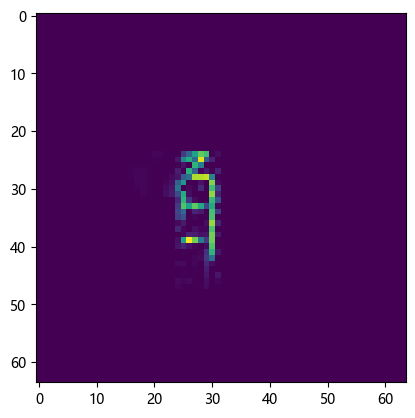

Predicted class: 9 | Logits: tensor([[-1.3308, -0.5269, -0.5216, -0.4415,  0.3152,  0.0026, -0.1378, -1.3177,
         -0.0310, -0.0560, -2.0448,  0.1838,  0.3595, -0.4890,  0.6887]])
Selected image for prediction: data/test\1000\input_62_5_13.jpg


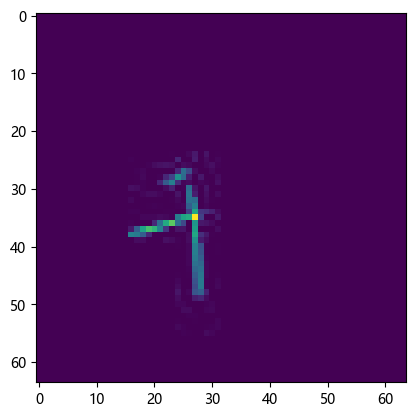

Predicted class: 6 | Logits: tensor([[-2.5116,  1.1092, -0.8298, -1.9855,  0.9121, -1.3879,  0.8224,  0.7849,
          0.7037, -0.2577, -2.3973,  1.4056, -0.7909,  1.1121, -0.6398]])
Selected image for prediction: data/test\10000\input_11_7_14.jpg


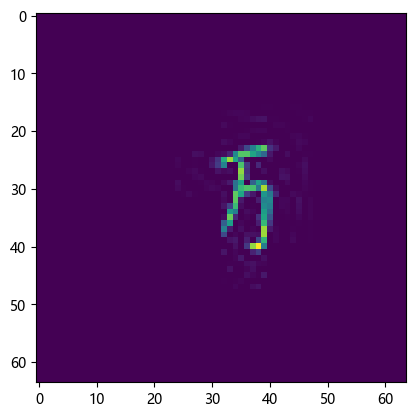

Predicted class: 10 | Logits: tensor([[-2.1502, -0.5179,  0.6660, -0.1850, -0.3235,  0.3451, -0.9949, -0.1477,
         -1.2306,  0.2201,  0.4917, -0.4720, -0.0763, -0.3397, -0.8303]])
Selected image for prediction: data/test\100000000\input_93_7_15.jpg


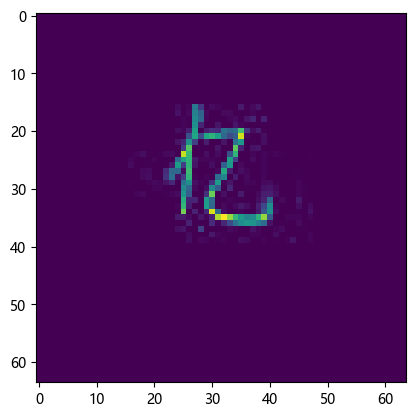

Predicted class: 9 | Logits: tensor([[ 0.2529, -3.1276, -1.2307,  0.1344,  0.1347,  0.8393, -0.5740, -2.5542,
         -0.4540,  0.3831, -0.5543,  0.0552, -0.8252, -1.9686,  1.1736]])
Selected image for prediction: data/test\2\input_23_1_3.jpg


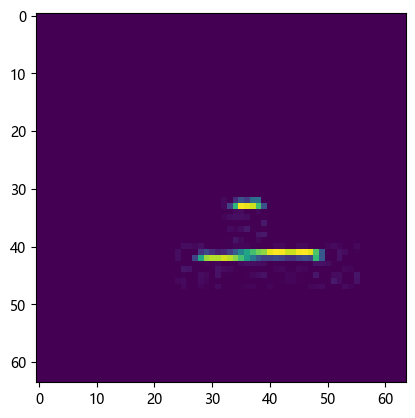

Predicted class: 2 | Logits: tensor([[-2.6625, -1.1633, -1.4122, -0.6110, -1.1490, -0.4795,  0.3512,  1.7835,
          0.8933, -1.7234, -0.0560, -0.0784,  0.3951,  0.5262,  0.0862]])
Selected image for prediction: data/test\3\input_95_2_4.jpg


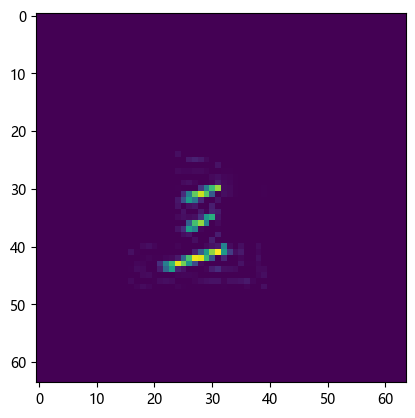

Predicted class: 3 | Logits: tensor([[-2.0379, -0.1540, -1.1772, -0.8320,  0.4999, -0.5498, -0.5711,  0.9342,
          1.3631, -0.9097, -0.7593,  0.4330, -0.6266,  0.3664, -0.4619]])
Selected image for prediction: data/test\4\input_11_7_5.jpg


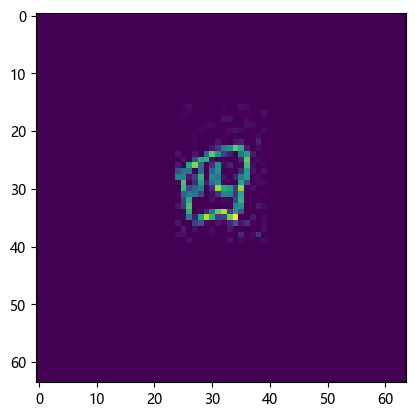

Predicted class: 9 | Logits: tensor([[-0.7106, -2.0367,  0.5568, -0.1757,  0.2811,  0.2345, -1.0953, -2.8154,
         -1.1831,  0.4419, -0.6855, -0.1766,  0.9674, -1.8389,  1.1266]])
Selected image for prediction: data/test\5\input_43_8_6.jpg


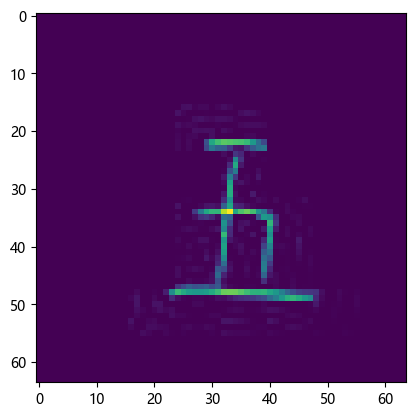

Predicted class: 5 | Logits: tensor([[-0.0246, -6.6746, -1.0202,  1.5650, -0.8999,  0.8543, -0.7218, -1.7767,
         -0.2878, -0.8013,  1.8984, -1.2669,  0.6211, -3.4318,  0.3525]])
Selected image for prediction: data/test\6\input_66_10_7.jpg


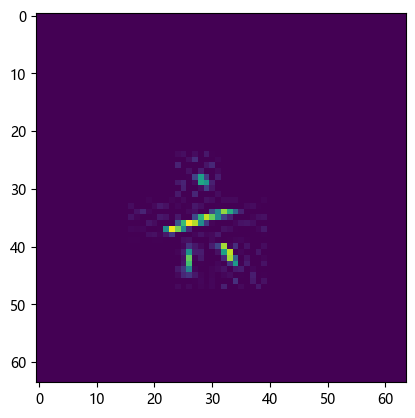

Predicted class: 2 | Logits: tensor([[-2.0566,  0.2900, -0.4552, -0.5968,  0.6266, -0.7225, -0.1956,  0.6968,
          0.6658, -0.6118, -1.3055,  0.4015, -0.0612, -0.4898, -0.4643]])
Selected image for prediction: data/test\7\input_61_5_8.jpg


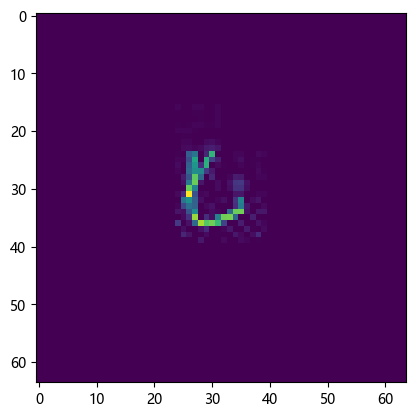

Predicted class: 9 | Logits: tensor([[-1.5636,  0.4860, -0.2467, -0.8792,  0.3808, -0.0017, -0.5572, -1.2683,
         -0.1480, -0.1113, -1.4620,  0.3782,  0.3708, -0.5628,  0.7690]])
Selected image for prediction: data/test\8\input_48_3_9.jpg


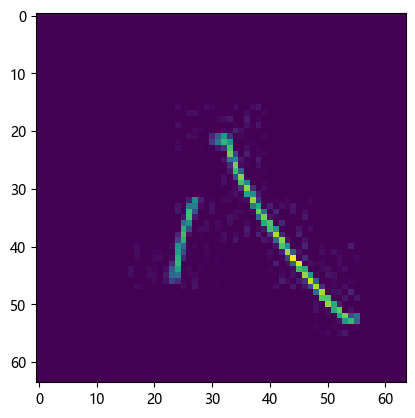

Predicted class: 8 | Logits: tensor([[-4.8388, -2.4803, -4.7523, -2.0935, -2.5782, -1.0179,  1.4852,  1.7261,
          0.8620, -1.1858,  1.1752,  0.4606,  0.0962,  4.2098,  0.8354]])
Selected image for prediction: data/test\9\input_43_2_10.jpg


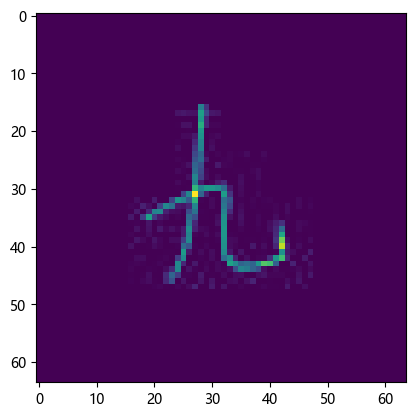

Predicted class: 9 | Logits: tensor([[-1.6329, -5.2083, -3.5589, -0.2484, -0.5768, -0.2617,  1.0442, -1.4395,
          0.2887, -0.0642, -0.5008,  0.6426,  0.5382, -1.7441,  1.7730]])


In [ ]:
import os
import re
import random
import torch
from torchinfo import summary
from preprocessing_utils import prepare_images, get_dataloaders, summarize_split, preview_random_images, show_batch
from models_utils import train_model, test_model, plot_confusion_matrix, plot_training_process, predict_image


class LogisticRegressionModel(torch.nn.Module):
    """
    Baseline 0: Logistic Regression for Chinese Characters.

    A single linear layer mapping `input_dim -> num_classes` trained with cross-entropy.
    Note: This module does not apply any activation or flattening internally.

    Args:
        input_dim (int): Number of input features per sample (e.g., 64*64 for a 1x64x64 image if flattened).
        num_classes (int): Number of target classes.
    """

    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, num_classes)

    def forward(self, x):
        """
        Compute logits for a batch.

        Args:
            x (torch.Tensor): Input tensor of shape `(batch_size, input_dim)`. Must be 2D and already flattened.

        Returns:
            torch.Tensor: Logits of shape `(batch_size, num_classes)`.
        """
        return self.linear(x)


if __name__ == "__main__":

    # Check PyTorch version
    print(torch.__version__)
    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Getting images ready
    # Prepare dataset
    root = prepare_images()
    print(f"Dataset ready at: {root}")
    # Summarize dataset
    summarize_split(str(root))
    # Preview random images
    preview_random_images(data_dir=str(root / "c_mnist"), n_images=9, grid_size=(3, 3))

    # Preprocessing
    # Get dataloaders
    dataloaders, datasets = get_dataloaders(data_dir="data", batch_size=64, image_size=(64, 64), augment=True)
    labels = datasets['train'].classes
    print("DataLoaders ready.")
    print(f"Classes: {labels}")

    show_batch(datasets["train"], n=12, cols=4)

    # Hyperparameters
    sample_batch = next(iter(dataloaders["train"]))[0]
    INPUT_DIM = sample_batch.shape[1] if sample_batch.ndim == 2 else sample_batch[0].numel()
    NUM_CLASSES = len(labels)
    # Batch sizes explored (kept small & large for gradient noise vs. stability comparison)
    BATCH_SIZE = [32, 256]
    EPOCHS = 30
    LEARNING_RATE = [0.01, 0.001, 0.0005]
    WEIGHT_DECAY = 5e-4
    MOMENTUM = 0.9  # For SGD
    PATIENCE = 5

    # Model definition
    log_reg_model = LogisticRegressionModel(input_dim=INPUT_DIM, num_classes=NUM_CLASSES).to(device)

    # Loss and optimizer
    criterion = torch.nn.CrossEntropyLoss()

    # Model summary
    print(f"Logistic Regression summary (input_dim={INPUT_DIM}, num_classes={NUM_CLASSES})")
    summary(log_reg_model, input_size=(1, INPUT_DIM), col_names=("input_size", "output_size", "num_params"))

    # Training
    dataloaders_dict = {}
    for bs in BATCH_SIZE:
        dl, _ = get_dataloaders(
            data_dir="data", batch_size=bs, image_size=(64, 64), augment=True)
        dataloaders_dict[bs] = dl
        print(f"DataLoaders for batch size {bs} ready.")

    total_acc_train_sgd = {}
    total_acc_validation_sgd = {}
    total_loss_train_sgd = {}
    total_loss_validation_sgd = {}

    total_acc_train_adam = {}
    total_acc_validation_adam = {}
    total_loss_train_adam = {}
    total_loss_validation_adam = {}

    for bs in BATCH_SIZE:
        print(f"\nTraining with batch size: {bs}")
        dataloaders = dataloaders_dict[bs]
        run_idx = 1
        for lr in LEARNING_RATE:
            # Adam run
            print(f"  Run {run_idx}: Adam optimizer with lr={lr}")
            model_adam = LogisticRegressionModel(INPUT_DIM, NUM_CLASSES).to(device)
            adam_opt = torch.optim.Adam(model_adam.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
            (
                acc_train_adam,
                loss_train_adam,
                acc_val_adam,
                loss_val_adam,
            ) = train_model(
                model_adam,
                dataloaders,
                adam_opt,
                criterion,
                epochs=EPOCHS,
                patience=PATIENCE,
                save_path=f"checkpoints/log_reg/model_{bs}_adam_{lr}.pth",
            )
            total_acc_train_adam[(bs, lr)] = acc_train_adam
            total_loss_train_adam[(bs, lr)] = loss_train_adam
            total_acc_validation_adam[(bs, lr)] = acc_val_adam
            total_loss_validation_adam[(bs, lr)] = loss_val_adam

            # SGD run
            print(f"  Run {run_idx}: SGD optimizer with lr={lr}, momentum={MOMENTUM}")
            model_sgd = LogisticRegressionModel(INPUT_DIM, NUM_CLASSES).to(device)
            sgd_opt = torch.optim.SGD(model_sgd.parameters(), lr=lr, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
            (
                acc_train_sgd,
                loss_train_sgd,
                acc_val_sgd,
                loss_val_sgd,
            ) = train_model(
                model_sgd,
                dataloaders,
                sgd_opt,
                criterion,
                epochs=EPOCHS,
                patience=PATIENCE,
                save_path=f"checkpoints/log_reg/model_{bs}_sgd_{lr}.pth",
            )
            total_acc_train_sgd[(bs, lr)] = acc_train_sgd
            total_loss_train_sgd[(bs, lr)] = loss_train_sgd
            total_acc_validation_sgd[(bs, lr)] = acc_val_sgd
            total_loss_validation_sgd[(bs, lr)] = loss_val_sgd

            run_idx += 1

    # Plotting training process
    for bs in BATCH_SIZE:
        for lr in LEARNING_RATE:
            print(f"\nPlotting training process for batch size {bs} and learning rate {lr} (SGD)")
            plot_training_process(
                total_acc_train_sgd[(bs, lr)],
                total_loss_train_sgd[(bs, lr)],
                total_acc_validation_sgd[(bs, lr)],
                total_loss_validation_sgd[(bs, lr)],
                f"plots/log_reg/training_process_{bs}_{lr}_sgd.png",
                plot=False
            )

            print(f"\nPlotting training process for batch size {bs} and learning rate {lr} (Adam)")
            plot_training_process(
                total_acc_train_adam[(bs, lr)],
                total_loss_train_adam[(bs, lr)],
                total_acc_validation_adam[(bs, lr)],
                total_loss_validation_adam[(bs, lr)],
                f"plots/log_reg/training_process_{bs}_{lr}_adam.png",
                plot=False
            )

    # Testing
    MODELS_DIR = "checkpoints/log_reg"

    best = {
        "path": None,
        "acc": 0.0,
        "f1": 0.0,
        "cm": None
    }

    # Iterate over all .pth files in directory
    if os.path.isdir(MODELS_DIR):
        for model_file in os.listdir(MODELS_DIR):
            if not model_file.endswith(".pth"):
                continue

            model_path = os.path.join(MODELS_DIR, model_file)
            print(f"\nTesting model: {model_path}")

            # Extract batch size from filename (model_32_adam_0.01.pth → 32)
            match = re.search(r"model_(\d+)_", model_file)
            if not match:
                print(f"Could not extract batch size from {model_file}, skipping...")
                continue
            batch_size = int(match.group(1))

            # Load model
            log_reg_model = LogisticRegressionModel(INPUT_DIM, NUM_CLASSES).to(device)
            log_reg_model.load_state_dict(torch.load(model_path, map_location=device))
            log_reg_model.eval()

            # Evaluate with correct dataloader
            test_loader = dataloaders_dict.get(batch_size, dataloaders_dict[BATCH_SIZE[0]])["test"]
            test_acc, f1, cm = test_model(log_reg_model, test_loader, criterion)

            print(f"Accuracy: {test_acc:.4f} | F1: {f1:.4f}")

            # Update best model
            if test_acc > best["acc"]:
                best.update({"path": model_path, "acc": test_acc, "f1": f1, "cm": cm})
                print(f"New best model: {model_path} (Acc: {test_acc:.4f}, F1: {f1:.4f})")
    else:
        print(f"Models directory not found: {MODELS_DIR}")

    # Plot training process and confusion matrix of the best model
    if best["cm"] is not None:
        print(f"\nBest model: {best['path']} | Acc: {best['acc']:.4f} | F1: {best['f1']:.4f}")
        plot_confusion_matrix(best["cm"], datasets["train"].classes)

    # Extract batch size and learning rate from best model filename
    m = re.search(r"model_(\d+)_(adam|sgd)_([0-9.]+)\.pth", os.path.basename(best["path"]))
    if m:
        batch_size = int(m.group(1))
        optimizer = m.group(2)
        learning_rate = float(m.group(3))
        print(f"Extracted batch size: {batch_size}, optimizer: {optimizer}, learning rate: {learning_rate}")
        if optimizer == "sgd":
            plot_training_process(
                total_acc_train_sgd[(batch_size, learning_rate)],
                total_loss_train_sgd[(batch_size, learning_rate)],
                total_acc_validation_sgd[(batch_size, learning_rate)],
                total_loss_validation_sgd[(batch_size, learning_rate)],
                f"plots/log_reg/best_model_training_process_{batch_size}_{learning_rate}_{optimizer}.png"
            )
        else:
            plot_training_process(
                total_acc_train_adam[(batch_size, learning_rate)],
                total_loss_train_adam[(batch_size, learning_rate)],
                total_acc_validation_adam[(batch_size, learning_rate)],
                total_loss_validation_adam[(batch_size, learning_rate)],
                f"plots/log_reg/best_model_training_process_{batch_size}_{learning_rate}_{optimizer}.png",
                plot=True
            )
    else:
        print("Could not extract parameters from best model filename. Skipping best-run plot.")

    # Inference on random images from test set
    # Collect one random image per class folder in data/test
    TEST_ROOT = "data/test"
    selected_images = []
    for cls in sorted(os.listdir(TEST_ROOT)):
        cls_dir = os.path.join(TEST_ROOT, cls)
        if not os.path.isdir(cls_dir):
            continue
        imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg",))]
        if not imgs:
            continue
        selected = os.path.join(cls_dir, random.choice(imgs))
        selected_images.append(selected)

    if best["path"]:
        log_reg_model = LogisticRegressionModel(INPUT_DIM, NUM_CLASSES).to(device)
        log_reg_model.load_state_dict(torch.load(best["path"], map_location=device))
        log_reg_model.eval()

        for img_path in selected_images:
            print(f"Selected image for prediction: {img_path}")
            prediction, logits = predict_image(
                model=log_reg_model,
                image_path=img_path,
                class_names=datasets['train'].classes,
                device=device,
            )
            # NOTE: 'logits' are raw scores; apply torch.softmax(logits, dim=0) for probabilities
            print(f"Predicted class: {prediction} | Logits: {logits}")
    else:
        print("No best model available; skipping inference.")
